In [ ]:
# ▶ Cell 1:Installing The Required Dependencies
!pip install --upgrade pip
!pip install \
    torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/metal \
    transformers datasets timm albumentations scikit-learn torchmetrics \
    grad-cam matplotlib onnx coremltools

In [ ]:
# ▶ Cell 2:Importing & Device Setup

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from datasets import load_dataset, DatasetDict
from transformers import ViTForImageClassification, get_linear_schedule_with_warmup
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score
import matplotlib.pyplot as plt

# Pick Apple Metal (MPS) if available, else CUDA, else CPU
device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device:", device)

Using device: mps


In [ ]:
# ▶ Cell 3:Download & Stratified Split of EyePACS

from sklearn.model_selection import train_test_split

raw = load_dataset("bumbledeep/eyepacs", split="train")  # ~38 k fundus images
indices = list(range(len(raw)))
labels = raw["label_code"]

# 15% held‑out test
trainval_idx, test_idx = train_test_split(
    indices, test_size=0.15, stratify=labels, random_state=42
)
# Of the remaining 85%, carve out ≈15% for validation (0.17647*0.85≈0.15)
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.17647,
    stratify=[labels[i] for i in trainval_idx],
    random_state=42,
)

ds = DatasetDict(
    {
        "train": raw.select(train_idx),
        "validation": raw.select(val_idx),
        "test": raw.select(test_idx),
    }
)
print("Split sizes:", {k: len(v) for k, v in ds.items()})

Split sizes: {'train': 24574, 'validation': 5267, 'test': 5267}


In [5]:
# ▶ Cell 4: Albumentations transforms
def get_albu_transforms(split):
    if split == "train":
        return A.Compose(
            [
                A.CenterCrop(224, 224),
                A.RandomRotate90(p=0.5),
                A.HorizontalFlip(p=0.5),
                A.CLAHE(clip_limit=2.0, p=0.2),
                A.RandomBrightnessContrast(p=0.2),
                A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                ToTensorV2(),
            ]
        )
    else:
        return A.Compose(
            [
                A.CenterCrop(224, 224),
                A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                ToTensorV2(),
            ]
        )

In [6]:
# ▶ Cell 5: Torch Dataset & DataLoaders
class EyePACSDataset(torch.utils.data.Dataset):
    def __init__(self, hf_ds, split):
        self.ds = hf_ds
        self.tf = get_albu_transforms(split)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        row = self.ds[idx]
        img = np.array(row["image"])
        aug = self.tf(image=img)
        return {
            "pixel_values": aug["image"],  # Tensor [3×224×224]
            "labels": int(row["label_code"]),
        }


batch_size = 32
train_dl = DataLoader(
    EyePACSDataset(ds["train"], "train"), batch_size=batch_size, shuffle=True
)
val_dl = DataLoader(
    EyePACSDataset(ds["validation"], "validation"), batch_size=batch_size, shuffle=False
)
test_dl = DataLoader(
    EyePACSDataset(ds["test"], "test"), batch_size=batch_size, shuffle=False
)

In [7]:
# ▶ Cell 6: Instantiate ViT‑Base and freeze first N blocks
num_labels = len(set(ds["train"]["label_code"]))
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=num_labels,
    ignore_mismatched_sizes=True,
).to(device)

# Optional: freeze the first 3 transformer blocks for faster convergence
freeze_at = 3
for i, blk in enumerate(model.vit.encoder.layer):
    if i < freeze_at:
        for p in blk.parameters():
            p.requires_grad = False

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
# ▶ Cell 7: Optimizer, scheduler, and loss function
epochs = 15
lr = 3e-5
total_steps = epochs * len(train_dl)
warmup_ratio = 0.2
warmup_steps = int(total_steps * warmup_ratio)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [9]:
# ▶ Cell 8: Training And Evaluation Routines
def train_one_epoch():
    model.train()
    running_loss = 0.0
    for batch in train_dl:
        imgs = batch["pixel_values"].to(device)
        lbls = batch["labels"].to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out.logits, lbls)
        loss.backward()
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()
    return running_loss / len(train_dl)


def evaluate(dl):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in dl:
            imgs = batch["pixel_values"].to(device)
            lbls = batch["labels"].cpu().numpy()
            logits = model(imgs).logits.cpu().numpy()
            all_logits.append(logits)
            all_labels.append(lbls)
    logits = np.concatenate(all_logits, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    preds = logits.argmax(-1)
    acc = accuracy_score(labels, preds)
    kappa = cohen_kappa_score(labels, preds, weights="quadratic")
    try:
        auc = roc_auc_score(
            labels, torch.softmax(torch.tensor(logits), 1).numpy(), multi_class="ovr"
        )
    except:
        auc = float("nan")
    return {"accuracy": acc, "kappa": kappa, "auc": auc}

In [10]:
# ▶ Cell 9 (updated): Training loop with history tracking
train_losses = []
val_accs = []
val_kappas = []
val_aucs = []

best_auc = 0.0
best_epoch = 0

for epoch in range(1, epochs + 1):
    loss = train_one_epoch()
    metrics = evaluate(val_dl)

    # record
    train_losses.append(loss)
    val_accs.append(metrics["accuracy"])
    val_kappas.append(metrics["kappa"])
    val_aucs.append(metrics["auc"])

    # print
    print(
        f"Epoch {epoch:2d} ▶ loss: {loss:.4f}  "
        f"val_acc: {metrics['accuracy']:.4f}  "
        f"val_kappa: {metrics['kappa']:.4f}  "
        f"val_auc: {metrics['auc']:.4f}"
    )

    # checkpoint best AUC
    if metrics["auc"] > best_auc:
        best_auc = metrics["auc"]
        best_epoch = epoch
        torch.save(model.state_dict(), "best_vital_eye.pt")

print(f"\n✅ Best val AUC {best_auc:.4f} at epoch {best_epoch}")

Epoch  1 ▶ loss: 1.1243  val_acc: 0.7532  val_kappa: 0.2713  val_auc: 0.7608
Epoch  2 ▶ loss: 0.9235  val_acc: 0.7558  val_kappa: 0.2778  val_auc: 0.7748
Epoch  3 ▶ loss: 0.8995  val_acc: 0.7676  val_kappa: 0.3977  val_auc: 0.8064
Epoch  4 ▶ loss: 0.8784  val_acc: 0.7657  val_kappa: 0.3613  val_auc: 0.8107
Epoch  5 ▶ loss: 0.8532  val_acc: 0.7744  val_kappa: 0.4455  val_auc: 0.8205
Epoch  6 ▶ loss: 0.8272  val_acc: 0.7771  val_kappa: 0.5400  val_auc: 0.8228
Epoch  7 ▶ loss: 0.7933  val_acc: 0.7695  val_kappa: 0.5597  val_auc: 0.8195
Epoch  8 ▶ loss: 0.7577  val_acc: 0.7731  val_kappa: 0.5017  val_auc: 0.8139
Epoch  9 ▶ loss: 0.7186  val_acc: 0.7703  val_kappa: 0.4730  val_auc: 0.7981
Epoch 10 ▶ loss: 0.6760  val_acc: 0.7604  val_kappa: 0.5416  val_auc: 0.7941
Epoch 11 ▶ loss: 0.6339  val_acc: 0.7562  val_kappa: 0.5224  val_auc: 0.7900
Epoch 12 ▶ loss: 0.5996  val_acc: 0.7537  val_kappa: 0.5129  val_auc: 0.7809
Epoch 13 ▶ loss: 0.5760  val_acc: 0.7465  val_kappa: 0.5297  val_auc: 0.7814

In [ ]:
# ▶ Cell 9.1: Plot training loss & val AUC over epochs
from transformers import ViTImageProcessor

# re‑instantiate the processor exactly as you did for training
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

# save the model & processor
model.save_pretrained("vital-eye-vit")
processor.save_pretrained("vital-eye-vit")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

['vital-eye-vit/preprocessor_config.json']

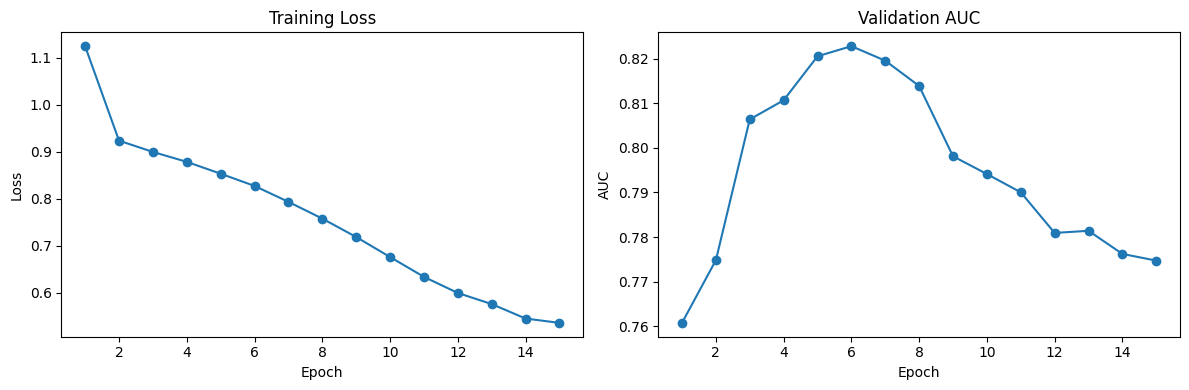

In [ ]:
# ▶ Cell 9.2: Plot training loss & val AUC over epochs
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_aucs, marker="o")
plt.title("Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")

plt.tight_layout()
plt.show()

In [12]:
# ▶ Cell 10: Load best checkpoint & evaluate on test set

# restore best model weights
model.load_state_dict(torch.load("best_vital_eye.pt", map_location=device))

# final evaluation
test_metrics = evaluate(test_dl)
print("📊 Test metrics (best-epoch):", test_metrics)

📊 Test metrics (best-epoch): {'accuracy': 0.774634516802734, 'kappa': np.float64(0.5398782739424715), 'auc': np.float64(0.8202626156032874)}


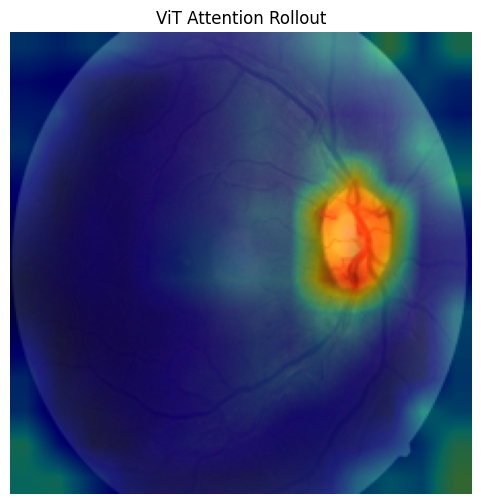

In [ ]:
# ▶ Cell 11 (fixed): ViT Attention‑Rollout Visualization
def attention_rollout(input_tensor, start_layer=0):
    outputs = model(input_tensor, output_attentions=True)
    attentions = (
        outputs.attentions
    )  # tuple: one Tensor per layer [batch, heads, tokens, tokens]
    batch_size, num_heads, num_tokens, _ = attentions[0].shape

    # initialize cumulative attention as identity
    result = (
        torch.eye(num_tokens, device=device).unsqueeze(0).expand(batch_size, -1, -1)
    )
    for i, attn in enumerate(attentions):
        if i < start_layer:
            continue
        # average heads
        attn_mat = attn.mean(dim=1)  # [batch, tokens, tokens]
        # add identity and normalize
        aug = attn_mat + torch.eye(num_tokens, device=device).unsqueeze(0)
        aug = aug / aug.sum(dim=-1, keepdim=True)
        result = aug @ result

    # extract class‑token attention to patches
    mask = result[:, 0, 1:]  # [batch, num_patches]
    size = int((num_tokens - 1) ** 0.5)
    mask = mask.reshape(batch_size, size, size)
    # upsample to full image size
    mask = F.interpolate(
        mask.unsqueeze(1), size=(224, 224), mode="bilinear", align_corners=False
    )
    return mask


# Visualize on first test image
sample = ds["test"][0]
img_np = np.array(sample["image"].resize((224, 224))) / 255.0
aug = get_albu_transforms("validation")(image=(img_np * 255).astype(np.uint8))
inp = aug["image"].unsqueeze(0).to(device)

# detach() before numpy()
mask = attention_rollout(inp)[0, 0].detach().cpu().numpy()
mask = (mask - mask.min()) / (mask.max() - mask.min())
heat = plt.cm.jet(mask)[..., :3]
overlay = 0.6 * img_np + 0.4 * heat

plt.figure(figsize=(6, 6))
plt.title("ViT Attention Rollout")
plt.axis("off")
plt.imshow(overlay)

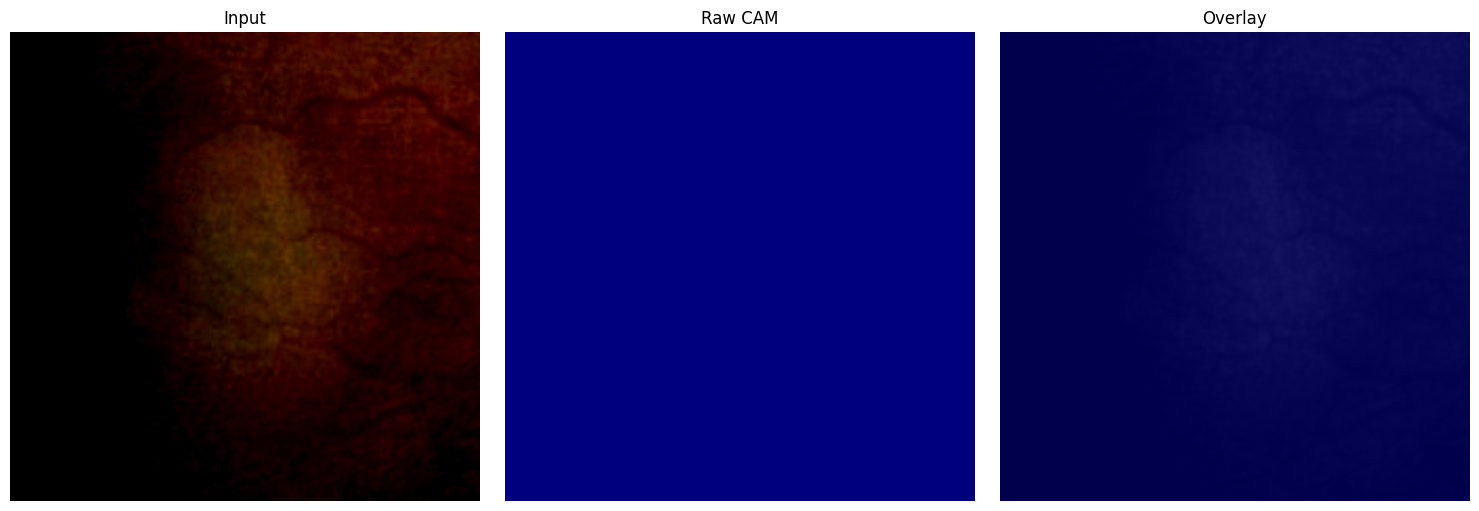

In [50]:
# Cell 12: Grad‑CAM with guarded hook and explicit removal

import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# 1) Identify the patch‑embedding layer
patch_proj = model.vit.embeddings.patch_embeddings.projection

# 2) Guarded forward‑hook
activations = []


def forward_hook(module, inp, out):
    if out.requires_grad:
        out.retain_grad()
        activations.append(out)


hook = patch_proj.register_forward_hook(forward_hook)

# 3) Grab a batch
batch = next(iter(test_dl))
images = batch["pixel_values"].to(device)  # [B,3,224,224]

# 4) Forward + backward on predicted score
model.zero_grad()
outputs = model(images)
logits = outputs.logits if hasattr(outputs, "logits") else outputs
preds = logits.argmax(dim=1)
scores = logits[torch.arange(len(preds)), preds]
scores.sum().backward()

# 5) Build and normalize the CAM
act = activations[0]  # [B,C,H',W']
grads = act.grad  # same shape
weights = grads.mean(dim=(2, 3), keepdim=True)  # [B,C,1,1]
cam = F.relu((weights * act).sum(dim=1, keepdim=True))  # [B,1,H',W']
cam = F.interpolate(
    cam, size=images.shape[-2:], mode="bilinear", align_corners=False  # [B,1,224,224]
)
cam = cam[0, 0].detach().cpu().numpy()  # [224,224]
cam = np.clip(cam * 1.5, 0, 1)  # contrast boost

# 6) De‑normalize input & prepare overlay
img = images[0].permute(1, 2, 0).cpu().numpy()  # H×W×3 in [-1,1]
img = (img + 1.0) / 2.0
img = np.clip(img, 0, 1)
gray = np.stack([img.mean(axis=2)] * 3, axis=2)  # grayscale background
heat = plt.cm.jet(cam)[..., :3]
overlay = np.clip(gray * 0.4 + heat * 0.6, 0, 1)

# 7) Clean up hook
hook.remove()

# 8) Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title("Input")
axes[0].axis("off")
axes[1].imshow(cam, cmap="jet")
axes[1].set_title("Raw CAM")
axes[1].axis("off")
axes[2].imshow(overlay)
axes[2].set_title("Overlay")
axes[2].axis("off")
plt.tight_layout()
plt.show()

Test‑set AUROC (DR vs no‑DR): 0.8076
Sensitivity @95% specificity: 0.4499


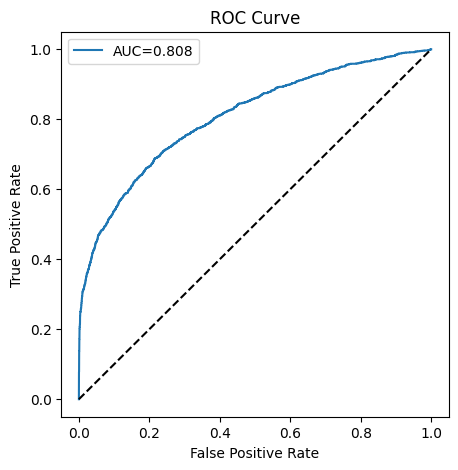

Quadratic‑weighted κ: 0.5399
Confusion Matrix:
 [[3713   13  132    1   12]
 [ 289   14   61    0    2]
 [ 450   16  305   11   11]
 [  23    0   79   23    6]
 [  29    0   42   10   25]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8244    0.9592    0.8867      3871
           1     0.3256    0.0383    0.0685       366
           2     0.4927    0.3846    0.4320       793
           3     0.5111    0.1756    0.2614       131
           4     0.4464    0.2358    0.3086       106

    accuracy                         0.7746      5267
   macro avg     0.5200    0.3587    0.3914      5267
weighted avg     0.7244    0.7746    0.7342      5267



In [52]:
# Cell 13 (adjusted) — make sure you've reloaded best‑epoch weights above
import torch
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import torch.nn.functional as F


def evaluate(model, dl, device):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in dl:
            imgs = batch["pixel_values"].to(device)
            labs = batch["labels"].to(device)
            out = model(imgs)
            logits = out.logits if hasattr(out, "logits") else out
            all_logits.append(logits.cpu())
            all_labels.append(labs.cpu())
    return torch.cat(all_logits, 0).numpy(), torch.cat(all_labels, 0).numpy()


# 0) reload best checkpoint here if needed…

# 1) get logits & labels
vit_logits, labels = evaluate(model, test_dl, device)

# 2) compute true p(DR)
probs = F.softmax(torch.from_numpy(vit_logits), dim=1).numpy()
binary_gt = (labels > 0).astype(int)
binary_preds = 1.0 - probs[:, 0]  # correct DR vs no‑DR score

# 3) AUC + ROC
auc = roc_auc_score(binary_gt, binary_preds)
print(f"Test‑set AUROC (DR vs no‑DR): {auc:.4f}")

fpr, tpr, _ = roc_curve(binary_gt, binary_preds)
spec = 1 - fpr
sens95 = tpr[spec >= 0.95].max()
print(f"Sensitivity @95% specificity: {sens95:.4f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 4) multi‑class κ & confusion
preds = vit_logits.argmax(axis=1)
qwk = cohen_kappa_score(labels, preds, weights="quadratic")
print(f"Quadratic‑weighted κ: {qwk:.4f}")

cm = confusion_matrix(labels, preds)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:")
print(classification_report(labels, preds, digits=4))

config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

blur sev=1: ViT=0.771, ResNet=0.001
blur sev=2: ViT=0.770, ResNet=0.001
blur sev=3: ViT=0.764, ResNet=0.002
brightness sev=1: ViT=0.744, ResNet=0.000
brightness sev=2: ViT=0.744, ResNet=0.000
brightness sev=3: ViT=0.743, ResNet=0.000


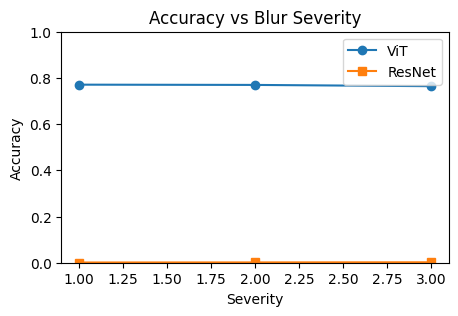

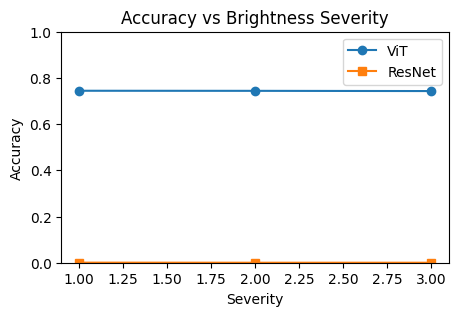

In [53]:
# Cell 14: Robustness Testing (ViT vs ResNet)

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms.functional import gaussian_blur, adjust_brightness
from transformers import ResNetForImageClassification

# 1) Load ResNet‑50 baseline
resnet_model = ResNetForImageClassification.from_pretrained("microsoft/resnet-50").to(
    device
)
resnet_model.eval()


# 2) Corruption helper
def corrupt(img: torch.Tensor, kind: str, severity: int) -> torch.Tensor:
    if kind == "blur":
        k = 3 + 2 * (severity - 1)
        return gaussian_blur(
            img.unsqueeze(0), kernel_size=(k, k), sigma=(severity, severity)
        ).squeeze(0)
    elif kind == "brightness":
        factor = {1: 0.5, 2: 1.0, 3: 1.5}[severity]
        return adjust_brightness(img, factor)
    else:
        raise ValueError(f"Unknown corruption kind {kind!r}")


# 3) Eval under corruption
def eval_corruption(model, dataloader, device, kind, sev):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in dataloader:
            imgs = batch["pixel_values"].to(device)
            labs = batch["labels"].to(device)
            corr = torch.stack([corrupt(im, kind, sev) for im in imgs]).to(device)
            out = model(corr)
            logits = out.logits if hasattr(out, "logits") else out
            preds = logits.argmax(dim=1)
            correct += (preds == labs).sum().item()
            total += labs.size(0)
    return correct / total


# 4) Sweep severities
kinds = ["blur", "brightness"]
severities = [1, 2, 3]
results = {"ViT": {}, "ResNet": {}}

for kind in kinds:
    for sev in severities:
        v_acc = eval_corruption(model, test_dl, device, kind, sev)
        r_acc = eval_corruption(resnet_model, test_dl, device, kind, sev)
        results["ViT"].setdefault(kind, []).append(v_acc)
        results["ResNet"].setdefault(kind, []).append(r_acc)
        print(f"{kind} sev={sev}: ViT={v_acc:.3f}, ResNet={r_acc:.3f}")

# 5) Plot
for kind in kinds:
    plt.figure(figsize=(5, 3))
    plt.plot(severities, results["ViT"][kind], "-o", label="ViT")
    plt.plot(severities, results["ResNet"][kind], "-s", label="ResNet")
    plt.title(f"Accuracy vs {kind.capitalize()} Severity")
    plt.xlabel("Severity")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()

In [64]:
# Cell 15: Export to ONNX & CoreML (fixed deployment target / ’mlprogram’ format)

import torch
import torch.nn as nn

# 0) Clear any stray hooks on the patch‑embed conv
patch = model.vit.embeddings.patch_embeddings.projection
if hasattr(patch, "_forward_hooks"):
    patch._forward_hooks.clear()
if hasattr(patch, "_backward_hooks"):
    patch._backward_hooks.clear()

# 1) Prepare a CPU copy for export
model_cpu = model.cpu().eval()

# 2) ONNX export (requires onnx)
try:
    import onnx  # noqa

    dummy = torch.randn(1, 3, 224, 224)
    torch.onnx.export(
        model_cpu,
        dummy,
        "vital_eye.onnx",
        input_names=["pixel_values"],
        output_names=["logits"],
        dynamic_axes={"pixel_values": {0: "batch"}, "logits": {0: "batch"}},
        opset_version=14,
    )
    print("✅ Saved ONNX model to vital_eye.onnx")
except ImportError:
    print("⚠️ Skipping ONNX export—install with `pip install onnx` to enable it.")

# 3) CoreML export (requires coremltools)
try:
    import coremltools as ct

    # Wrap so forward returns only the logits tensor:
    class LogitsOnly(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            return self.model(x).logits

    wrapper = LogitsOnly(model_cpu).eval()
    traced = torch.jit.trace(wrapper, torch.randn(1, 3, 224, 224), strict=False)

    # For macOS12 / iOS15+, CoreML must use the “mlprogram” format (extension .mlpackage)
    mlmodel = ct.convert(
        traced,
        inputs=[
            ct.ImageType(
                name="pixel_values",
                shape=(1, 3, 224, 224),
                scale=1 / 255.0,
                bias=[-0.5, -0.5, -0.5],
            )
        ],
        minimum_deployment_target=ct.target.macOS12,  # or ct.target.iOS15
        # convert_to defaults to "mlprogram" for this target
    )

    mlmodel.save("ViTalEye.mlpackage")
    print("✅ Saved CoreML model to ViTalEye.mlpackage")
except ImportError:
    print(
        "⚠️ Skipping CoreML export—install with `pip install coremltools` to enable it."
    )

# 4) (Optional) move your model back to the original device
model.to(device)

✅ Saved ONNX model to vital_eye.onnx


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 349.02 passes/s]


✅ Saved CoreML model to ViTalEye.mlpackage


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed